# 5.1 Classification

Create a classification model using logistic regression.

* Reference: [LogisticRegression docs](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)
* Train a model that classifies the type of flower using (i) 2 features (sepal length and width) and (ii) all 4 features. Create a testing dataset of 25% for validation.
* Visualize the model.
* Create a confusion matrix.
* Compute precision and recall for every class in your model.

In [1]:
!pip install scikit-learn matplotlib numpy pandas

In [2]:
%matplotlib inline
import os, sys
from sklearn import linear_model, datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

In [3]:
iris = datasets.load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['target'] = iris.target
iris_df["target_name"]=iris['target_names'][iris_df['target']]
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [4]:
# Select features
X_2_features = iris.data[:, :2]  # Only sepal length and sepal width
X_4_features = iris.data         # All 4 features
y = iris.target

# Split dataset into 75% training and 25% testing
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2_features, y, test_size=0.25, random_state=42)
X_train_4, X_test_4, y_train_4, y_test_4 = train_test_split(X_4_features, y, test_size=0.25, random_state=42)

# Train Logistic Regression model with 2 features
logreg_2 = linear_model.LogisticRegression(max_iter=200)
logreg_2.fit(X_train_2, y_train_2)

# Train Logistic Regression model with 4 features
logreg_4 = linear_model.LogisticRegression(max_iter=200)
logreg_4.fit(X_train_4, y_train_4)

print("Both models trained successfully!")

Both models trained successfully!


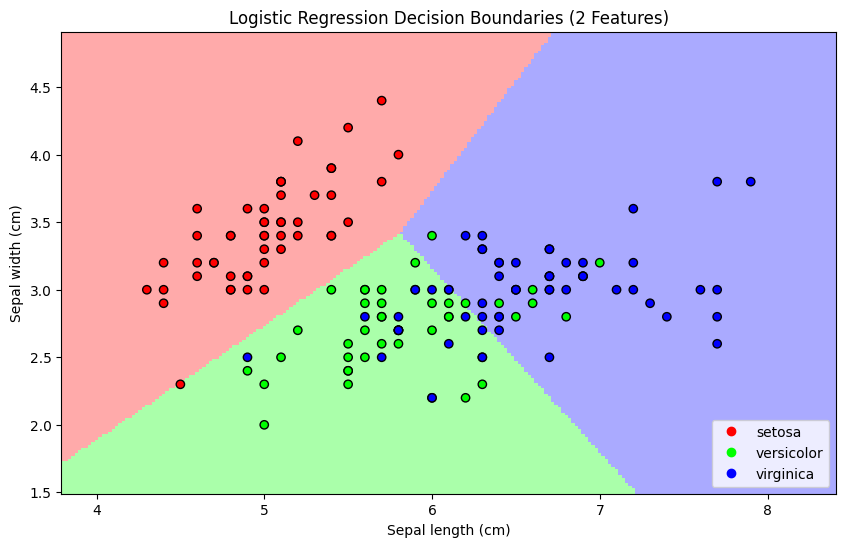

In [5]:
from matplotlib.colors import ListedColormap

# Define boundaries for the plot based on the 2-feature dataset
x_min, x_max = X_2_features[:, 0].min() - 0.5, X_2_features[:, 0].max() + 0.5
y_min, y_max = X_2_features[:, 1].min() - 0.5, X_2_features[:, 1].max() + 0.5
h = 0.02  # Step size in the mesh

# Create a meshgrid to plot the decision boundaries
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = logreg_2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the results
plt.figure(figsize=(10, 6))
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

plt.pcolormesh(xx, yy, Z, cmap=cmap_light)
scatter = plt.scatter(X_2_features[:, 0], X_2_features[:, 1], c=y, edgecolors='k', cmap=cmap_bold)

plt.xlabel('Sepal length (cm)')
plt.ylabel('Sepal width (cm)')
plt.title('Logistic Regression Decision Boundaries (2 Features)')
plt.legend(handles=scatter.legend_elements()[0], labels=list(iris.target_names), loc='lower right')
plt.show()

--- 2-FEATURE MODEL EVALUATION ---

Classification Report (Precision & Recall):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.78      0.64      0.70        11
   virginica       0.71      0.83      0.77        12

    accuracy                           0.84        38
   macro avg       0.83      0.82      0.82        38
weighted avg       0.85      0.84      0.84        38


--- 4-FEATURE MODEL EVALUATION ---

Classification Report (Precision & Recall):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      1.00      1.00        11
   virginica       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



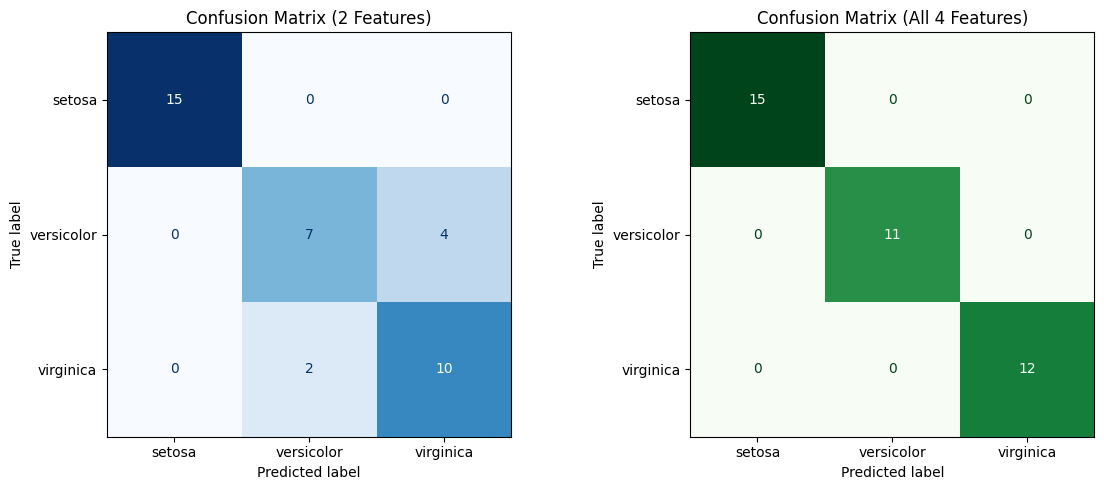

In [6]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# --- Evaluate 2-Feature Model ---
y_pred_2 = logreg_2.predict(X_test_2)
print("--- 2-FEATURE MODEL EVALUATION ---")
print("\nClassification Report (Precision & Recall):")
print(classification_report(y_test_2, y_pred_2, target_names=iris.target_names))

# --- Evaluate 4-Feature Model ---
y_pred_4 = logreg_4.predict(X_test_4)
print("\n--- 4-FEATURE MODEL EVALUATION ---")
print("\nClassification Report (Precision & Recall):")
print(classification_report(y_test_4, y_pred_4, target_names=iris.target_names))

# --- Plot Confusion Matrices ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix for 2 Features
cm_2 = confusion_matrix(y_test_2, y_pred_2)
disp_2 = ConfusionMatrixDisplay(confusion_matrix=cm_2, display_labels=iris.target_names)
disp_2.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title("Confusion Matrix (2 Features)")

# Confusion Matrix for 4 Features
cm_4 = confusion_matrix(y_test_4, y_pred_4)
disp_4 = ConfusionMatrixDisplay(confusion_matrix=cm_4, display_labels=iris.target_names)
disp_4.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title("Confusion Matrix (All 4 Features)")

plt.tight_layout()
plt.show()